### Disclaimer

This tutorial assumes that you have already familiarized yourself with the Autoencodix pipeline and thus only briefly touches on topics like data preparation and training your Autoencodix models.
If you are not yet familiar with these topics, the other tutorial notebooks in this repo are a good reference.

---

## Overview

Hyperparameter optimization allows you to systematically search over model parameters such as batch size, learning rate, network depth, and regularization strength. Instead of choosing these values manually, a hyperparameter optimization (HPO) framework like Syne Tune can be used to sample different configurations, run the model, evaluate it, and use the results to guide future trials.

Each trial follows this workflow:

1. Build a model configuration from sampled hyperparameters.
2. Train the model on the provided dataset.
3. Evaluate the learned embedding on downstream machine-learning tasks or other metrics like reconstruction loss.
4. Report evaluation metrics back to the optimizer.

The optimizer then uses an optimization algorithm to efficiently decide which hyperparameters to try next.

---

# Hyperparameter Optimization with Autoencodix using Syne Tune

This tutorial explains how to perform hyperparameter optimization (HPO) for Autoencodix models using Syne Tune. More information and documentation can be found here: https://github.com/syne-tune/syne-tune. The goal is to automatically find good training settings for a chosen architecture by evaluating many different configurations and selecting the one with the best (downstream) performance.

Prerequisites:
 * training data
 * an Autoencodix model, e.g. Vanillix, Ontix, etc.

This tutorial covers all the necessary steps:
  * specifying which parameters should be optimized
  * defining a training function
  * choosing an optimization algorithm
  * running the optimizer
  * and finally retrieving the best configuration

---



## Step 0: Install Syne Tune

To install Syne Tune from pip:

```
pip install 'syne-tune'
```

or to install the latest version from source:
```
git clone https://github.com/syne-tune/syne-tune.git
cd syne-tune
pip install -e .
```

## Step 1: Defining the Configuration Space

### Hyperparameter Configuration Space

First, we need to decide which parameters of our model we want to optimize and what values they can take. This is called the configuration space. We define the configuration space as a dictionary which is passed to the Syne Tune scheduler in order to sample and evaluate a model configuration.

In this case, some parameters are fixed and stay the same for all trials, such as the number of training epochs or the loss aggregation strategy.
Other parameters are defined as ranges or choices, which can be sampled from, such as:

* Batch size
* Dropout probability
* Encoder width factor
* Weight decay
* Learning rate
* Number of layers
* Regularization parameters

The full list of configurable parameters can be found in DefaultConfig.py

---


In [1]:
from syne_tune.config_space import randint, uniform, loguniform

tasks = ["condition"]

# Hyperparameter configuration space
config_space = {
	## Fixed params
	"epochs": 100,
	"checkpoint_interval": 25,
	"loss_reduction": "sum",
	## Tunable params
	"batch_size": randint(128, 4096),
	"drop_p": uniform(0.0, 0.9),
	"enc_factor": randint(1, 5),
	"weight_decay": loguniform(1e-5, 1e-1),
	"beta": loguniform(1e-5, 10),
	"learning_rate": loguniform(1e-5, 1e-1),
	"n_layers": randint(2, 5),
    # Downstream tasks to evaluate on
    "tasks": "$".join(["condition"])
}

## Step 2: Choosing objective and algorithm

Now that we have defined a search space, we need to define our optimization goal, i.e. the metric we want to improve. In our case, we want to asses our model on two dimensions. First, how well our learned embeddings performs on downstream tasks, like classifying cancer types. Secondly, how much information our embedding retains, i.e. the reconstruction loss.

Once we have decided on a metric, we need to choose an optimization algorithm. Syne Tune provides several optimizers to efficiently find good hyperparameter configurations. In this case we choose CQR (Conformalized Quantile Regression).

To properly work, we need to provide the optimizer with several parameters:
* The search space, to sample configurations.
* The performance metric to optimize.
* The optimization direction, so whether we want to minimize or maximize our metric value.




In [2]:
from syne_tune.optimizer.baselines import CQR

#metric = "downstream_performance"
metric = "reconstruction_loss"
if metric == "downstream_performance":
	do_minimize = False
else:
	do_minimize = True

# Scheduler (i.e. Optimizer)
scheduler = CQR(
    config_space=config_space,
    metric=metric,
    do_minimize=do_minimize
)

## Step 3: Defining the Objective Function


### Objective Function

The core of the optimization is the training or objective function. This function defines what happens in a single trial.

For each hyperparameter configuration proposed by the optimizer, the training function:

1. Instantiates and trains the model with a sampled configuration on the dataset.
2. Evaluates the learned embedding by computing performance metrics such as downstream performance and reconstruction loss.
3. Reports these metrics back to Syne Tune.

Syne Tune treats this function as a black box: it only cares about the input hyperparameters and the reported metrics.

---



In [3]:
def objective_function(
	## Fixed params
	epochs: int,
	checkpoint_interval: int,
	loss_reduction: str,
	## Tunable params
	batch_size: int,
	drop_p: float,
	enc_factor: int,
	weight_decay: float,
	beta: float,
	learning_rate: float,
	n_layers: int,
    # List of tasks for downstream evaluation
    tasks: str,

):
	from autoencodix.data.datapackage import DataPackage
	from autoencodix.configs.vanillix_config import VanillixConfig
	import sklearn
	from sklearn import linear_model
	import autoencodix as acx
	from syne_tune import Reporter
	from autoencodix.utils.example_data import raw_protein, raw_rna, annotation
	from autoencodix.configs.default_config import DataCase

	# Step 3.1 instantiating our model with a given configuration
    # Our dataset
	my_datapackage = DataPackage(
    	multi_bulk={"rna": raw_rna, "protein": raw_protein},
    	annotation={"paired": annotation},
	)

    # The sampled configuration
	myconfig = VanillixConfig(
			## Fixed params
			data_case=DataCase.MULTI_BULK,
			epochs=epochs,
			checkpoint_interval= checkpoint_interval,
			loss_reduction= loss_reduction,
        	device="cpu",
			## Tunable params
			batch_size= batch_size,
			drop_p= drop_p,
			enc_factor= enc_factor,
			weight_decay= weight_decay,
			beta= beta,
			learning_rate= learning_rate,
			n_layers= n_layers,
			)

	vanillix = acx.Vanillix(data=my_datapackage, config=myconfig)
	vanillix.run()

	# Step 3.2 Evaluating our learned embedding
    # The reconstruction loss is provided directly by autoencodix
	reconstruction_loss = float(vanillix.result.sub_losses.get("recon_loss").get(epoch=-1, split="valid"))

    # Compute the downstream performance
    # We define a list of tasks which are either regression or classification tasks from our annotation file.
    # A linear model is used on the learned embedding to compute the performance for each task.
	sklearn.set_config(enable_metadata_routing=True)

	# Define Classifier
	sklearn_ml_class = linear_model.LogisticRegression(
		solver="sag",
		n_jobs=-1,
		class_weight="balanced",
		max_iter=200,
	)
    # Define Regressor
	sklearn_ml_regression = linear_model.LinearRegression() # Unused, only needed if downstream task is regression variable

    # Downstream performance metrics
	own_metric_class = 'roc_auc_ovo'
	own_metric_regression = 'r2'

	# make sure the task list has the proper type for autoencodix evaluate function
	tasks_list = [t for s in (tasks.split("$") if isinstance(tasks,str) else tasks) for t in (s.split("$") if isinstance(s,str) else [s])]

	vanillix.evaluate(
		ml_model_class=sklearn_ml_class,
		ml_model_regression=sklearn_ml_regression,
		params= tasks_list,
		metric_class = own_metric_class,
		metric_regression = own_metric_regression,
		reference_methods = [], # No reference methods for tuning
		split_type = "use-split",
		n_downsample = None, # Use a subset of the data for faster evaluation
	)

	# here we take the average over all downstream tasks
	downstream_performance = vanillix.result.embedding_evaluation.loc[
		vanillix.result.embedding_evaluation.score_split == "valid",
		"value"
	].mean()

    # We instantiate the Syne Tune Reporter and pass the model performance back to our Tuner
	report = Reporter()
	report(downstream_performance=downstream_performance, reconstruction_loss=reconstruction_loss)


## Step 4: Running the Optimization

Once the objective function and search space are defined, we create the tuner. The tuner coordinates the optimization process by:

* Sampling hyperparameter configurations using the optimizer.
* Launching trials using the training function.
* Collecting reported metrics.

The optimizer runs until a stopping criterion is met, such as a maximum number of completed trials or a certain amount of time.

---



In [4]:
from syne_tune import Tuner, StoppingCriterion
from syne_tune.experiments import load_experiment
from syne_tune.backend import PythonBackend
from syne_tune.optimizer.baselines import CQR

# Define the Tuner
tuner = Tuner(
    trial_backend=PythonBackend(tune_function=objective_function, config_space=config_space),
    scheduler=scheduler,
    stop_criterion=StoppingCriterion(
		#max_wallclock_time=300,  # How long the optimization process may run in seconds
		max_num_trials_completed=10, # Number of different hyperparameter configurations which are evaluated
		),
    n_workers=1,  # how many trials are evaluated in parallel
)

# Start tuning
tuner.run()

# We load relevant information stored by Syne Tune.
tuning_experiment = load_experiment(tuner.name)



🚀 Syne Tune - Hyperparameter Optimization
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📋 Experiment Configuration
├─ Name: python-entrypoint-2026-01-06-11-38-15-455
├─ Backend: PythonBackend
├─ Workers: 1
├─ Scheduler: CQR
├─ Results Path: /Users/lucathale-bombien/syne-tune/python-entrypoint-2026-01-06-11-38-15-455
└─ Log Path: /Users/lucathale-bombien/syne-tune/python-entrypoint-2026-01-06-11-38-15-455

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🏁 Starting hyperparameter optimization...
[12:38:15] 🚀 Trial 0 started - config: epochs=100, checkpoint_interval=25, loss_reduction=sum, batch_size=2551, drop_p=0.8636488958909204, enc_factor=5, weight_decay=0.07776356337560063, beta=4.082749409092568, learning_rate=0.009377922565626454, n_layers=2, tasks=condition
[12:38:25] ✅ Trial 0 completed!
[12:38:25] 🚀 Trial 1 started - config: epochs=100, checkpoint_interval=25, loss_reduction=sum, batch_size=823, drop_p=0.635

/Users/lucathale-bombien/PycharmProjects/autoencodix_package_dev/.venv/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


[12:39:10] 🚀 Trial 5 started - config: epochs=100, checkpoint_interval=25, loss_reduction=sum, batch_size=2666, drop_p=0.0030178922018332943, enc_factor=3, weight_decay=0.014299759280339304, beta=0.005047156237200351, learning_rate=2.7284801034072225e-05, n_layers=2, tasks=condition
[12:39:20] ✅ Trial 5 completed!


/Users/lucathale-bombien/PycharmProjects/autoencodix_package_dev/.venv/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


[12:39:21] 🚀 Trial 6 started - config: epochs=100, checkpoint_interval=25, loss_reduction=sum, batch_size=3982, drop_p=0.7685645669297791, enc_factor=1, weight_decay=0.00010986162093961166, beta=0.00010858740155490102, learning_rate=0.04926421972212471, n_layers=5, tasks=condition

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📊 Tuning Status (last metric is reported)
 trial_id     status  iter  epochs  checkpoint_interval loss_reduction  batch_size   drop_p  enc_factor  weight_decay     beta  learning_rate  n_layers     tasks  downstream_performance  reconstruction_loss  worker-time
        0  Completed     1     100                   25            sum        2551 0.863649           5      0.077764 4.082749       0.009378         2 condition                0.650246           191.960938     0.000012
        1  Completed     1     100                   25            sum         823 0.635718           5      0.096640 0.082056       0.000215         2 co

...

/Users/lucathale-bombien/PycharmProjects/autoencodix_package_dev/.venv/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


[12:39:57] 🚀 Trial 9 started - config: epochs=100, checkpoint_interval=25, loss_reduction=sum, batch_size=1193, drop_p=0.06294672914204115, enc_factor=4, weight_decay=0.0029756648352616427, beta=0.00010687122041560436, learning_rate=0.046449197541839016, n_layers=2, tasks=condition

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📊 Tuning Status (last metric is reported)
 trial_id     status  iter  epochs  checkpoint_interval loss_reduction  batch_size   drop_p  enc_factor  weight_decay     beta  learning_rate  n_layers     tasks  downstream_performance  reconstruction_loss  worker-time
        0  Completed     1     100                   25            sum        2551 0.863649           5      0.077764 4.082749       0.009378         2 condition                0.650246           191.960938     0.000012
        1  Completed     1     100                   25            sum         823 0.635718           5      0.096640 0.082056       0.000215         2 c

/Users/lucathale-bombien/PycharmProjects/autoencodix_package_dev/.venv/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


[12:40:07] 🚀 Trial 10 started - config: epochs=100, checkpoint_interval=25, loss_reduction=sum, batch_size=1716, drop_p=0.005019216719299513, enc_factor=4, weight_decay=0.0004156830637845455, beta=0.0001542502785451385, learning_rate=0.07259431960210584, n_layers=5, tasks=condition
[12:40:17] ✅ Trial 10 completed!
[12:40:17] 🚀 Trial 11 started - config: epochs=100, checkpoint_interval=25, loss_reduction=sum, batch_size=1503, drop_p=0.04688061635604327, enc_factor=1, weight_decay=0.00025460102008993484, beta=3.081079568314798e-05, learning_rate=0.015219860755495283, n_layers=2, tasks=condition

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🎉🎉🎉 HYPERPARAMETER OPTIMIZATION COMPLETE!
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

--------------------
Resource summary (last result is reported):
 trial_id     status  iter  epochs  checkpoint_interval loss_reduction  batch_size   drop_p  enc_factor  weight_decay     beta  l

/Users/lucathale-bombien/PycharmProjects/autoencodix_package_dev/.venv/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


## Visualizing the Optimization process

### Best Performance over Time

/Users/lucathale-bombien/PycharmProjects/autoencodix_package_dev/.venv/lib/python3.12/site-packages/syne_tune/experiments/experiment_result.py:139: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


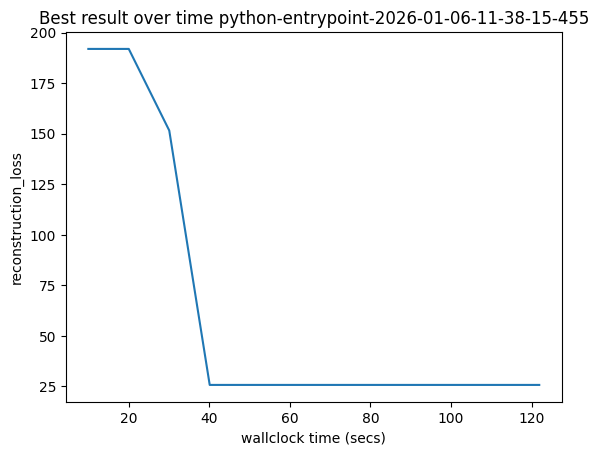

In [5]:
tuning_experiment.plot()

### Scatterplot of all trials

/Users/lucathale-bombien/PycharmProjects/autoencodix_package_dev/.venv/lib/python3.12/site-packages/syne_tune/experiments/experiment_result.py:178: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


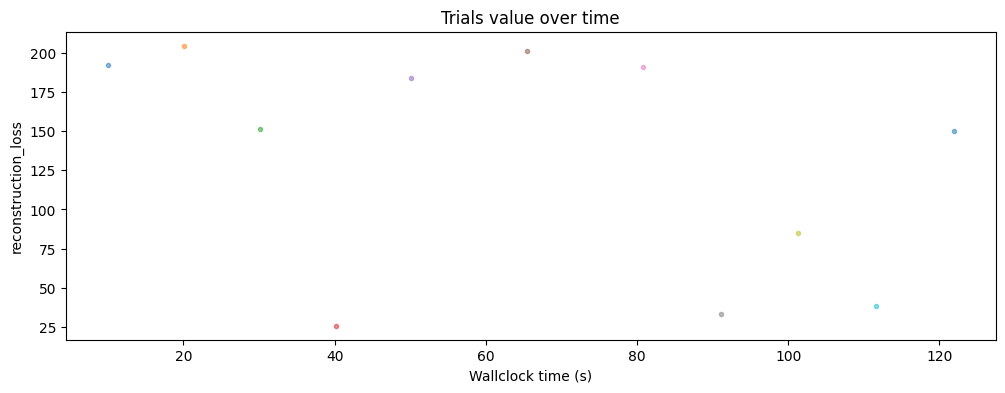

In [6]:
tuning_experiment.plot_trials_over_time()

### Comparing tuning on Reconstruction Loss vs. Downstream Performance

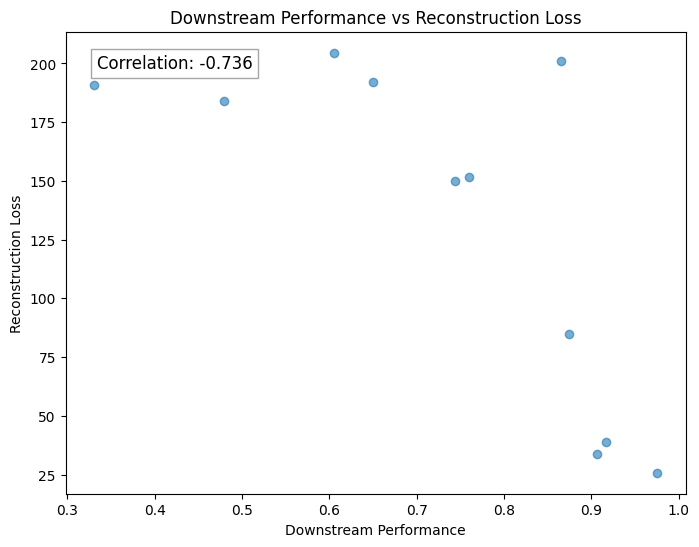

In [7]:
import numpy as np

import matplotlib.pyplot as plt

y = tuning_experiment.results.reconstruction_loss
x = tuning_experiment.results.downstream_performance

corr = np.corrcoef(x, y)[0, 1]

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.6)
plt.xlabel("Downstream Performance")
plt.ylabel("Reconstruction Loss")
plt.title("Downstream Performance vs Reconstruction Loss")
# plt.xlim(0.8, 1.0) ## Limit to good and very good runs
# plt.ylim(500, 600) ##

plt.text(
	0.05, 0.95,
	f"Correlation: {corr:.3f}",
	transform=plt.gca().transAxes,
	fontsize=12,
	verticalalignment='top',
	bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray')
)

plt.show()


## Selecting and Saving the Best Configuration

After the optimization finishes, the experiment results can be loaded and queried for the best configuration. The “best” configuration is defined as the one that achieved the highest (or lowest, depending on the metric) reported performance on the validation data.

This configuration can then be reused for final training or further experiments.

---

In [11]:
print(f"best result found: {tuning_experiment.best_config()}")

import pickle

with open("tuning_experiment.pkl", "wb") as f:
    pickle.dump(tuning_experiment, f)

print("Saved tuning_experiment.pkl")

with open("tuning_experiment.pkl", "rb") as f:
# with open("./large_ontix_save/large_ontix_syne_tune_experiment_recon.pkl", "rb") as f:
	tuning_experiment = pickle.load(f)
print("loaded tuning_experiment.pkl")

best result found: {'downstream_performance': 0.9756944444444444, 'reconstruction_loss': 25.77974853515625, 'trial_id': 3, 'config_epochs': 100, 'config_checkpoint_interval': 25, 'config_loss_reduction': 'sum', 'config_batch_size': 1581, 'config_drop_p': 0.0223448386659114, 'config_enc_factor': 1, 'config_weight_decay': 0.0001133359274981, 'config_beta': 0.0008579860880328, 'config_learning_rate': 0.0451006955485194, 'config_n_layers': 2, 'config_tasks': 'condition'}
Saved tuning_experiment.pkl
loaded tuning_experiment.pkl
